In [103]:
using PyPlot
using JLD2
using Statistics
import PhysicalConstants.CODATA2018: c_0, ħ
using Unitful

In [104]:
pathdir_old_ds = "Y:/TwoDGas/2025/07/04"
pathdir_new_ds = "Y:/TwoDGas/2026/01/19/0046"

N = 10
n0 = 1e3#1279#1e1
r = 100
λ = 421e-9
γ = 32.7e6 # In Hz
Γ = 2.02e8 # In Hz

x_crop = [1100:1700;]
y_crop = [1750:2450;]

ω0 = 2π*ustrip(c_0)/λ

radius_droplets = 12 # In pxls
size_pxl = 0.187e-6
N_atoms_per_droplet = 15000

Isat = ustrip(ħ)*Γ*ω0^3 / (12*π*ustrip(c_0)^2)
Isat /= ustrip(ħ)*ω0*N_atoms_per_droplet; # Convert to photon/m^2/atom

### Load experimental data

In [105]:
# Old dataset
@load "Saved_exp_data/Intensity_integrated_droplets_"*join(split(pathdir_old_ds, "/")[3:end], "_")*".jld2" Sat Iatoms_drop Ibkg_drop Idark_drop Mean_atoms Mean_bkg Mean_dark Mean_bkg_atoms Std_atoms Std_bkg Std_dark Std_bkg_atoms
Sat_old_ds, Iatoms_old_ds, Ibkg_old_ds, Idark_old_ds, Mean_atoms_old_ds, Mean_bkg_old_ds, Mean_dark_old_ds, Mean_bkg_atoms_old_ds, Std_atoms_old_ds, Std_bkg_old_ds, Std_dark_old_ds, Std_bkg_atoms_old_ds = Sat, Iatoms_drop, Ibkg_drop, Idark_drop, Mean_atoms, Mean_bkg, Mean_dark, Mean_bkg_atoms, Std_atoms, Std_bkg, Std_dark, Std_bkg_atoms;

In [106]:
# New dataset
@load "Saved_exp_data/Intensity_integrated_droplets_"*join(split(pathdir_new_ds, "/")[3:end], "_")*".jld2" Sat Iatoms_drop Ibkg_drop Idark_drop Mean_atoms Mean_bkg Mean_dark Mean_bkg_atoms Std_atoms Std_bkg Std_dark Std_bkg_atoms
Sat_new_ds, Iatoms_new_ds, Ibkg_new_ds, Idark_new_ds, Mean_atoms_new_ds, Mean_bkg_new_ds, Mean_dark_new_ds, Mean_bkg_atoms_new_ds, Std_atoms_new_ds, Std_bkg_new_ds, Std_dark_new_ds, Std_bkg_atoms_new_ds = Sat, Iatoms_drop, Ibkg_drop, Idark_drop, Mean_atoms, Mean_bkg, Mean_dark, Mean_bkg_atoms, Std_atoms, Std_bkg, Std_dark, Std_bkg_atoms;

### Load simulations

In [107]:
@load "Solutions_sim/Itot_N_$(N)_r_100_sat_[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60]_n0_$(n0)_decay_rate_up_down.jdl2" Sat Itot I_SE_SR_SS I_SR_SR_SS nbr_error_t_N;

### Plot the experimental data

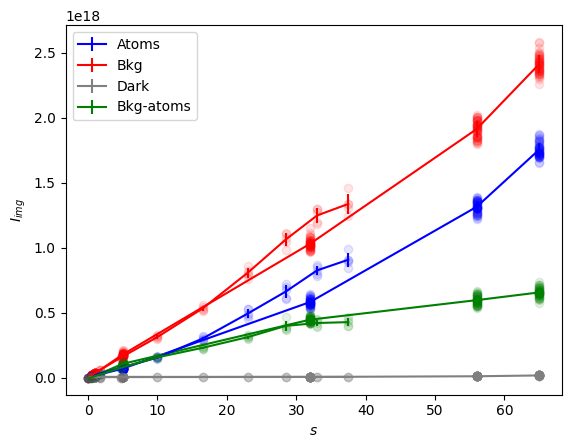

In [108]:
close("all")
fig = subplots()

# Old dataset
errorbar(Sat_old_ds, Mean_atoms_old_ds, yerr=Std_atoms_old_ds, label="Atoms", color="b")
errorbar(Sat_old_ds, Mean_bkg_old_ds, yerr=Std_bkg_old_ds, label="Bkg", color="r")
errorbar(Sat_old_ds, Mean_dark_old_ds, yerr=Std_dark_old_ds, label="Dark", color="grey")
errorbar(Sat_old_ds, Mean_bkg_atoms_old_ds, yerr=Std_bkg_atoms_old_ds, label="Bkg-atoms", color="green")

for i = 1:length(Sat_old_ds)
    for j = 1:size(Iatoms_old_ds)[2]
        scatter(Sat_old_ds[i], Iatoms_old_ds[i, j], color="b", alpha = 0.1)
        scatter(Sat_old_ds[i], Ibkg_old_ds[i, j], color="r", alpha = 0.1)
        scatter(Sat_old_ds[i], Idark_old_ds[i, j], color="grey", alpha = 0.1)
        scatter(Sat_old_ds[i], Ibkg_old_ds[i, j]-Iatoms_old_ds[i, j], color="g", alpha = 0.1)
    end
end

# New dataset
errorbar(Sat_new_ds, Mean_atoms_new_ds, yerr=Std_atoms_new_ds, color="b")
errorbar(Sat_new_ds, Mean_bkg_new_ds, yerr=Std_bkg_new_ds, color="r")
errorbar(Sat_new_ds, Mean_dark_new_ds, yerr=Std_dark_new_ds, color="grey")
errorbar(Sat_new_ds, Mean_bkg_atoms_new_ds, yerr=Std_bkg_atoms_new_ds, color="green")

for i = 1:length(Sat_new_ds)
    for j = 1:size(Iatoms_new_ds)[2]
        scatter(Sat_new_ds[i], Iatoms_new_ds[i, j], color="b", alpha = 0.1)
        scatter(Sat_new_ds[i], Ibkg_new_ds[i, j], color="r", alpha = 0.1)
        scatter(Sat_new_ds[i], Idark_new_ds[i, j], color="grey", alpha = 0.1)
        scatter(Sat_new_ds[i], Ibkg_new_ds[i, j]-Iatoms_new_ds[i, j], color="g", alpha = 0.1)
    end
end

xlabel(L"s")
ylabel(L"I_{img}")

legend()

# pygui(true); show();
pygui(false);

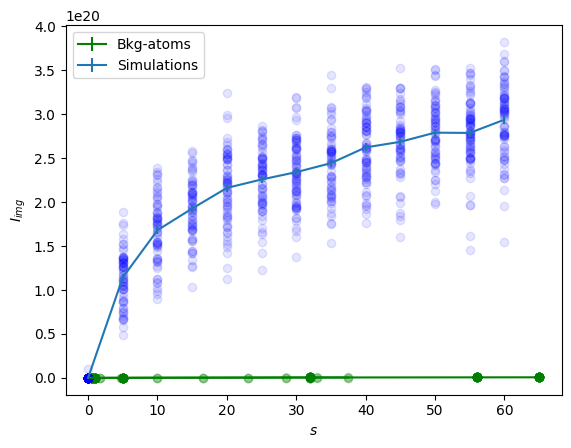

In [109]:
close("all")
fig = subplots()

# Old dataset
errorbar(Sat_old_ds, Mean_bkg_atoms_old_ds, yerr=Std_bkg_atoms_old_ds, label="Bkg-atoms", color="green")

for i = 1:length(Sat_old_ds)
    for j = 1:size(Iatoms_old_ds)[2]
        scatter(Sat_old_ds[i], Ibkg_old_ds[i, j]-Iatoms_old_ds[i, j], color="g", alpha = 0.1)
    end
end

# New dataset
errorbar(Sat_new_ds, Mean_bkg_atoms_new_ds, yerr=Std_bkg_atoms_new_ds, color="green")

for i = 1:length(Sat_new_ds)
    for j = 1:size(Iatoms_new_ds)[2]
        scatter(Sat_new_ds[i], Ibkg_new_ds[i, j]-Iatoms_new_ds[i, j], color="g", alpha = 0.1)
    end
end


# Simulations
errorbar(Sat, [mean([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(Sat)], yerr=[std([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r-length(nbr_error_t_N[i])) for i in 1:length(Sat)], label="Simulations")

for i in 1:length(Sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(Sat[i], Itot[i, j], alpha=0.1, color="blue")
        end
    end
end

xlabel(L"s")
ylabel(L"I_{img}")

legend()

# pygui(true); show();
pygui(false);

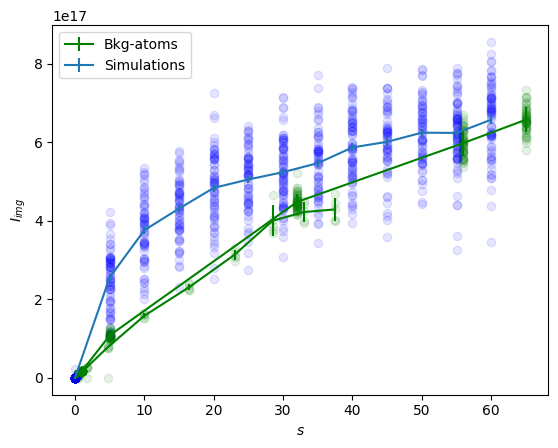

In [110]:
factor_prop = maximum(Mean_bkg_atoms_old_ds)/maximum([mean([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(Sat)])

close("all")
fig = subplots()

# Old dataset
errorbar(Sat_old_ds, Mean_bkg_atoms_old_ds, yerr=Std_bkg_atoms_old_ds, label="Bkg-atoms", color="green")

for i = 1:length(Sat_old_ds)
    for j = 1:size(Iatoms_old_ds)[2]
        scatter(Sat_old_ds[i], Ibkg_old_ds[i, j]-Iatoms_old_ds[i, j], color="g", alpha = 0.1)
    end
end

# New dataset
errorbar(Sat_new_ds, Mean_bkg_atoms_new_ds, yerr=Std_bkg_atoms_new_ds, color="green")

for i = 1:length(Sat_new_ds)
    for j = 1:size(Iatoms_new_ds)[2]
        scatter(Sat_new_ds[i], Ibkg_new_ds[i, j]-Iatoms_new_ds[i, j], color="g", alpha = 0.1)
    end
end


# Simulations
errorbar(Sat, factor_prop*[mean([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(Sat)], yerr=factor_prop*[std([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r-length(nbr_error_t_N[i])) for i in 1:length(Sat)], label="Simulations")

for i in 1:length(Sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(Sat[i], factor_prop*Itot[i, j], alpha=0.1, color="blue")
        end
    end
end

xlabel(L"s")
ylabel(L"I_{img}")

legend()

# pygui(true); show();
pygui(false);

In [111]:
factor_prop

0.0022386958898039217

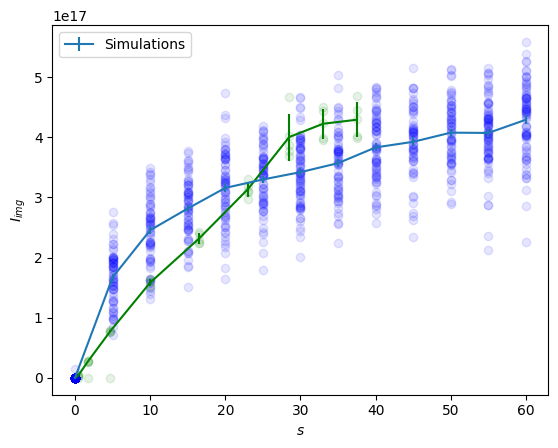

In [112]:
factor_prop = maximum(Mean_bkg_atoms_new_ds)/maximum([mean([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(Sat)])

close("all")
fig = subplots()

# Old dataset
# errorbar(Sat_old_ds, Mean_bkg_atoms_old_ds, yerr=Std_bkg_atoms_old_ds, label="Bkg-atoms", color="green")

# for i = 1:length(Sat_old_ds)
#     for j = 1:size(Iatoms_old_ds)[2]
#         scatter(Sat_old_ds[i], Ibkg_old_ds[i, j]-Iatoms_old_ds[i, j], color="g", alpha = 0.1)
#     end
# end

# New dataset
errorbar(Sat_new_ds, Mean_bkg_atoms_new_ds, yerr=Std_bkg_atoms_new_ds, color="green")

for i = 1:length(Sat_new_ds)
    for j = 1:size(Iatoms_new_ds)[2]
        scatter(Sat_new_ds[i], Ibkg_new_ds[i, j]-Iatoms_new_ds[i, j], color="g", alpha = 0.1)
    end
end


# Simulations
errorbar(Sat, factor_prop*[mean([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(Sat)], yerr=factor_prop*[std([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r-length(nbr_error_t_N[i])) for i in 1:length(Sat)], label="Simulations")

for i in 1:length(Sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(Sat[i], factor_prop*Itot[i, j], alpha=0.1, color="blue")
        end
    end
end

xlabel(L"s")
ylabel(L"I_{img}")

legend()

# pygui(true); show();
pygui(false);

In [113]:
factor_prop

0.0014611200445051647

### Plot as a function of Sat measured from the mean images bkg

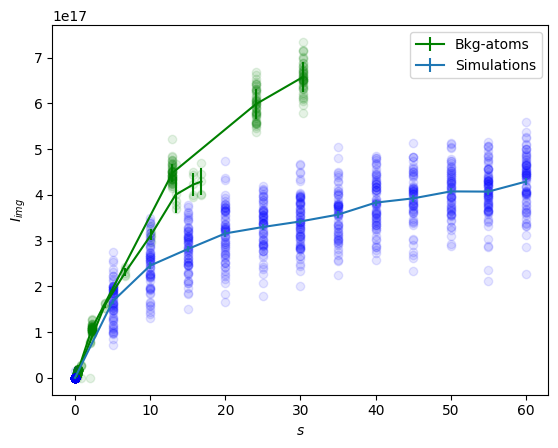

In [114]:
close("all")
fig = subplots()

# Old dataset
# errorbar(Mean_bkg_old_ds/Isat, Mean_atoms_old_ds, yerr=Std_atoms_old_ds, label="Atoms", color="b")
# errorbar(Mean_bkg_old_ds/Isat, Mean_bkg_old_ds, yerr=Std_bkg_old_ds, color="r", label="Bkg")
# errorbar(Mean_bkg_old_ds/Isat, Mean_dark_old_ds, yerr=Std_dark_old_ds, label="Dark", color="grey")
errorbar(Mean_bkg_old_ds/Isat, Mean_bkg_atoms_old_ds, yerr=Std_bkg_atoms_old_ds, label="Bkg-atoms", color="green")


for i = 1:length(Sat_old_ds)
    for j = 1:size(Iatoms_old_ds)[2]
        # scatter(Mean_bkg_old_ds[i]/Isat, Iatoms_old_ds[i, j], color="b", alpha = 0.1)
        # scatter(Mean_bkg_old_ds[i]/Isat, Ibkg_old_ds[i, j], color="r", alpha = 0.1)
        # scatter(Mean_bkg_old_ds[i]/Isat, Idark_old_ds[i, j], color="grey", alpha = 0.1)
        scatter(Mean_bkg_old_ds[i]/Isat, Ibkg_old_ds[i, j]-Iatoms_old_ds[i, j], color="g", alpha = 0.1)
    end
end

# New dataset
# errorbar(Mean_bkg_new_ds/Isat, Mean_atoms_new_ds, yerr=Std_atoms_new_ds, color="b")
# errorbar(Mean_bkg_new_ds/Isat, Mean_bkg_new_ds, yerr=Std_bkg_new_ds, color="r")
# errorbar(Mean_bkg_new_ds/Isat, Mean_dark_new_ds, yerr=Std_dark_new_ds, color="grey")
errorbar(Mean_bkg_new_ds/Isat, Mean_bkg_atoms_new_ds, yerr=Std_bkg_atoms_new_ds, color="green")

for i = 1:length(Sat_new_ds)
    for j = 1:size(Iatoms_new_ds)[2]
        # scatter(Mean_bkg_new_ds[i]/Isat, Iatoms_new_ds[i, j], color="b", alpha = 0.1)
        # scatter(Mean_bkg_new_ds[i]/Isat, Ibkg_new_ds[i, j], color="r", alpha = 0.1)
        # scatter(Mean_bkg_new_ds[i]/Isat, Idark_new_ds[i, j], color="grey", alpha = 0.1)
        scatter(Mean_bkg_new_ds[i]/Isat, Ibkg_new_ds[i, j]-Iatoms_new_ds[i, j], color="g", alpha = 0.1)
    end
end

# Simulations
errorbar(Sat, factor_prop*[mean([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(Sat)], yerr=factor_prop*[std([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r-length(nbr_error_t_N[i])) for i in 1:length(Sat)], label="Simulations")

for i in 1:length(Sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(Sat[i], factor_prop*Itot[i, j], alpha=0.1, color="blue")
        end
    end
end

xlabel(L"s")
ylabel(L"I_{img}")

legend()

pygui(true); show();
pygui(false);

### Plot as a function of Sat measured from the each images bkg

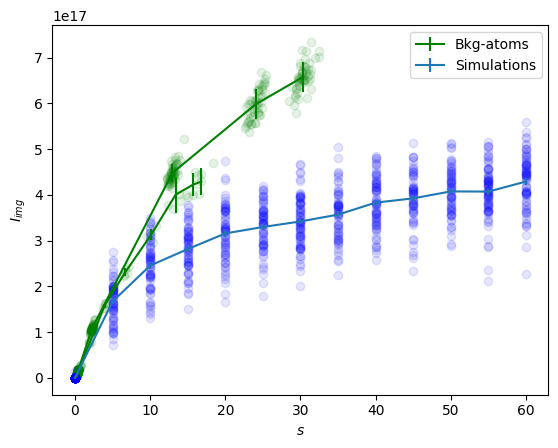

In [115]:
close("all")
fig = subplots()

# Old dataset
# errorbar(Mean_bkg_old_ds/Isat, Mean_atoms_old_ds, yerr=Std_atoms_old_ds, label="Atoms", color="b")
# errorbar(Mean_bkg_old_ds/Isat, Mean_bkg_old_ds, yerr=Std_bkg_old_ds, color="r", label="Bkg")
# errorbar(Mean_bkg_old_ds/Isat, Mean_dark_old_ds, yerr=Std_dark_old_ds, label="Dark", color="grey")
errorbar(Mean_bkg_old_ds/Isat, Mean_bkg_atoms_old_ds, yerr=Std_bkg_atoms_old_ds, label="Bkg-atoms", color="green")


for i = 1:length(Sat_old_ds)
    for j = 1:size(Iatoms_old_ds)[2]
        # scatter(Mean_bkg_old_ds[i]/Isat, Iatoms_old_ds[i, j], color="b", alpha = 0.1)
        # scatter(Mean_bkg_old_ds[i]/Isat, Ibkg_old_ds[i, j], color="r", alpha = 0.1)
        # scatter(Mean_bkg_old_ds[i]/Isat, Idark_old_ds[i, j], color="grey", alpha = 0.1)
        scatter(Ibkg_old_ds[i, j]/Isat, Ibkg_old_ds[i, j]-Iatoms_old_ds[i, j], color="g", alpha = 0.1)
    end
end

# New dataset
# errorbar(Mean_bkg_new_ds/Isat, Mean_atoms_new_ds, yerr=Std_atoms_new_ds, color="b")
# errorbar(Mean_bkg_new_ds/Isat, Mean_bkg_new_ds, yerr=Std_bkg_new_ds, color="r")
# errorbar(Mean_bkg_new_ds/Isat, Mean_dark_new_ds, yerr=Std_dark_new_ds, color="grey")
errorbar(Mean_bkg_new_ds/Isat, Mean_bkg_atoms_new_ds, yerr=Std_bkg_atoms_new_ds, color="green")

for i = 1:length(Sat_new_ds)
    for j = 1:size(Iatoms_new_ds)[2]
        # scatter(Mean_bkg_new_ds[i]/Isat, Iatoms_new_ds[i, j], color="b", alpha = 0.1)
        # scatter(Mean_bkg_new_ds[i]/Isat, Ibkg_new_ds[i, j], color="r", alpha = 0.1)
        # scatter(Mean_bkg_new_ds[i]/Isat, Idark_new_ds[i, j], color="grey", alpha = 0.1)
        scatter(Ibkg_new_ds[i, j]/Isat, Ibkg_new_ds[i, j]-Iatoms_new_ds[i, j], color="g", alpha = 0.1)
    end
end

# Simulations
errorbar(Sat, factor_prop*[mean([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(Sat)], yerr=factor_prop*[std([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r-length(nbr_error_t_N[i])) for i in 1:length(Sat)], label="Simulations")

for i in 1:length(Sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(Sat[i], factor_prop*Itot[i, j], alpha=0.1, color="blue")
        end
    end
end

xlabel(L"s")
ylabel(L"I_{img}")

legend()

pygui(true); show();
pygui(false);